In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


In [4]:
filepath = "/content/audio1.wav"
y, sr = librosa.load(filepath,sr = None)
print(f"sample rate : {sr} Hz")
print(f"Duration : {len(y)/ sr:.2f} seconds")
print(f"No of samples : {y}")
print(f"shape : {y.shape}")






sample rate : 48000 Hz
Duration : 5.46 seconds
No of samples : [0.         0.         0.         ... 0.02639771 0.02886963 0.03012085]
shape : (262123,)


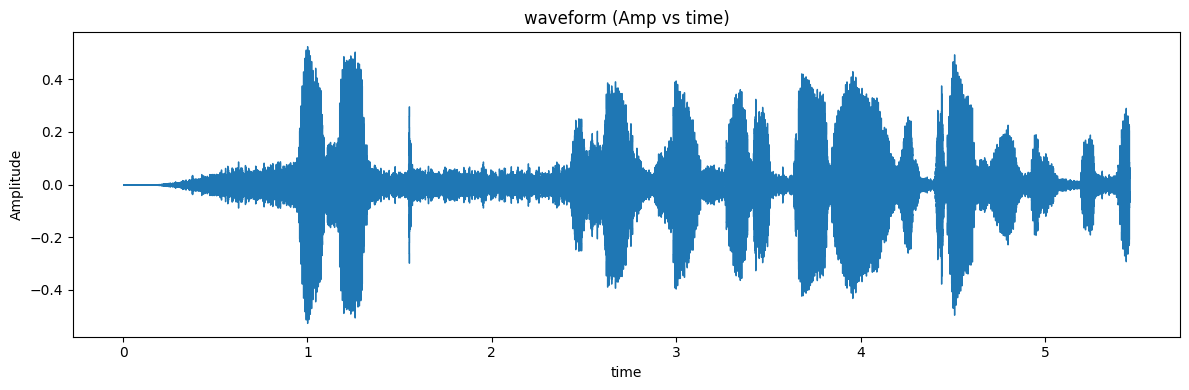

In [5]:
plt.figure(figsize = (12,4))
librosa.display.waveshow(y,sr=sr)
plt.title("waveform (Amp vs time)")
plt.xlabel("time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("Waveform.png")
plt.show()




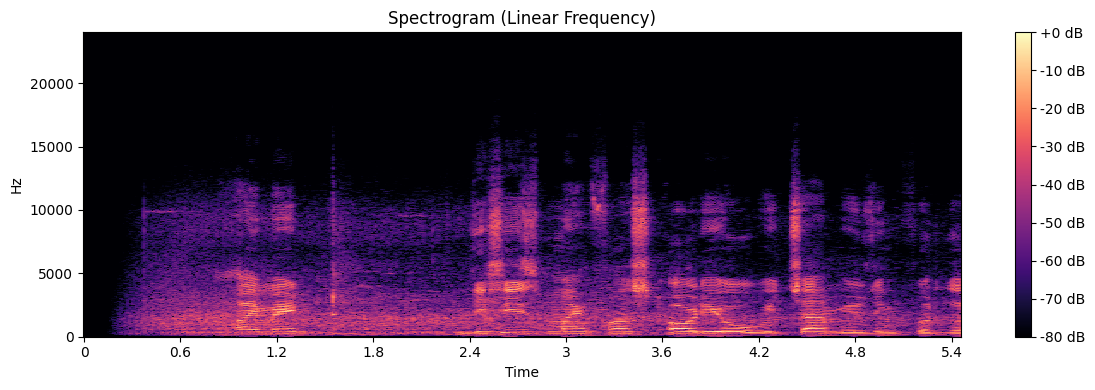

In [7]:
## compute and plot STFT

D = librosa.stft(y)
s_db =librosa.amplitude_to_db(np.abs(D), ref = np.max)
plt.figure(figsize = (12,4))
librosa.display.specshow(s_db, sr=sr, x_axis = 'time', y_axis='hz')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Linear Frequency)")
plt.tight_layout()
plt.savefig("spectrogram.png")
plt.show()



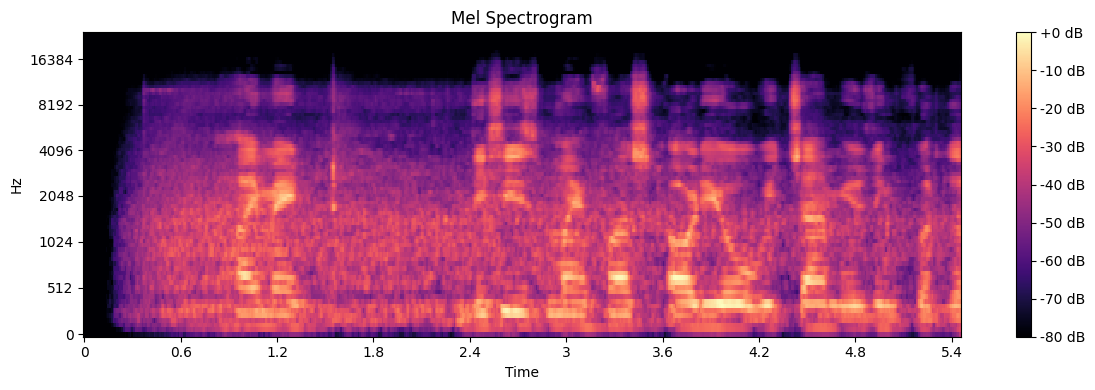

In [9]:
#convert into melspectogram

melspec = librosa.feature.melspectrogram(y=y,sr=sr,n_mels = 80)
melspec_db = librosa.power_to_db(melspec, ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.savefig("mel_spectrogram.png")
plt.show()

In [10]:
target_sr = 16000  #standard for deppdram/stt models
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

print(f"\nOriginal sample rate: {sr} Hz, samples: {len(y)}")
print(f"Resampled to: {target_sr} Hz, samples: {len(y_resampled)}")


mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"\nMFCC shape: {mfccs.shape}")


Original sample rate: 48000 Hz, samples: 262123
Resampled to: 16000 Hz, samples: 87375

MFCC shape: (13, 512)
